# Numeric interferometer usage

**What you'll learn:**
- How to set up a numeric interferometer using `NumericBraggInterferometer`
- How to plot interferometer arm trajectories from the numeric tree
- How to define beamsplitter and free-evolution functions using `propagate`
- How to simulate an atom cloud and compute interferometer output ellipses
- How to sweep detuning and compute output port populations

In [1]:
import numpy as np
from mwave.integrate import make_kvec, make_phi
from mwave.numeric import NumericBraggInterferometer
from mwave.simulation_utils import cloud_init
from scipy.integrate import solve_ivp
import numpy as np
from numba import jit, float64

# Set interferometer parameters
omega_r_conversion = 2066*2*np.pi
nbragg = 4
T = 4.5e-3*omega_r_conversion
Tp = 8e-3*omega_r_conversion
    
# Initialize kvec and tree
ifr = NumericBraggInterferometer(-2*nbragg, 4*nbragg, distance=4) # Should pass in wavefunction initialization functions

ifr.split(nbragg) # Should pass in the relevant function here as well! Function will inspect input function arguments to ensure correct number and naming
ifr.propagate(T)
ifr.split(nbragg)
ifr.propagate(Tp)
ifr.split([3*nbragg, -nbragg])
ifr.propagate(T)
ifr.split([3*nbragg, -nbragg])

Plot the trajectories

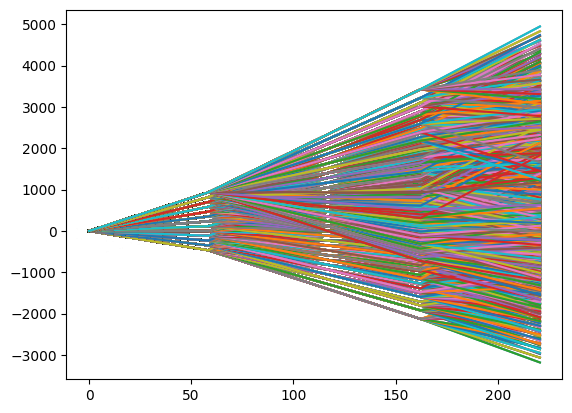

In [2]:
from matplotlib import pyplot as plt

nodes = ifr.get_nodes()
nA, nB, nC, nD = nodes[4*nbragg], nodes[2*nbragg], nodes[0.0*nbragg], nodes[-2*nbragg]
Ts = [0, 0, T, T, T + Tp, T + Tp, T + Tp + T, T + Tp + T]

plt.figure()
for nn in [nA, nB, nC, nD]:
    for p in nn:
        for node in nn[p]:
            t, x = node.get_trajectory()
            plt.plot(t, x)
plt.show()

Create function for simulating the full interferometer

In [3]:
from mwave.integrate import propagate, omega_fnc_gaussian, multi_omega_fnc, phase_fnc_constant
from mwave.simulation_utils import cloud_init

Omega0 = 19.5
w0 = 6.2e-3
sigma = 0.259658916
t_bragg = 6 * sigma

def deltalookup(vz):
    return 4*nbragg + 4*(vz/0.0035)

def omegalookup(x, y, z):
    return Omega0*np.exp(-2*(x**2 + y**2)/(w0**2))

def cpops(x0, y0, z0, vz, vx, vy, cphase=0.0, injected_dphase=0.0):
    natoms = len(x0)
    cache = {}

    def calc_bs(x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, z, idx):
        multifrequency = isinstance(klattice, list)

        # Phase injection at pulse 3
        extra_phase = 0.0
        if idx == 3:
            extra_phase = cphase
            if k_init == 0.0 and k_final == -2.0*nbragg:
                extra_phase += injected_dphase

        # Check cache (keyed by pulse index, initial state, and phase)
        cache_key = (idx, k_init, extra_phase)
        if cache_key not in cache:
            # Per-atom Rabi frequency from beam profile
            x = x0 + vx*t
            y = y0 + vy*t
            omegas_arr = omegalookup(x, y, z0 + z)

            # Per-atom detuning from velocity
            deltas_arr = deltalookup(vz)

            # Initial state (all atoms start at k_init)
            phi0_batch = np.zeros((natoms, len(ifr.kvec)), dtype=np.complex128)
            phi0_batch[:, np.argmin(np.abs(ifr.kvec - k_init))] = 1.0

            # Choose omega function based on single vs multifrequency
            if multifrequency:
                o_fn = multi_omega_fnc
                o_args = np.array([1.0, sigma, t_bragg/2, 8*4])
            else:
                o_fn = omega_fnc_gaussian
                o_args = np.array([1.0, sigma, t_bragg/2])

            result = propagate(
                ifr.kvec, phi0_batch, t + t_bragg, deltas_arr,
                o_fn, o_args,
                phase_fnc_constant, np.array([extra_phase]),
                omegas=omegas_arr, t0=t, tol=1e-8,
            )
            cache[cache_key] = result.phi_final

        kf_idx = np.argmin(np.abs(ifr.kvec - k_final))
        return cache[cache_key][:, kf_idx]

    # Free evolution: phase accumulates as exp(-i*k^2*t)
    propfnc = lambda x0, y0, z0, vz, vx, vy, t, k: np.exp(-1j*t*k**2)

    # Wire up beamsplitter functions for each pulse
    fnclst = [
        lambda x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x: calc_bs(x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x, 1),
        propfnc,
        lambda x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x: calc_bs(x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x, 2),
        propfnc,
        lambda x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x: calc_bs(x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x, 3),
        propfnc,
        lambda x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x: calc_bs(x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x, 4),
    ]
    ifr.set_operation_funcs(fnclst)

    popfnc = ifr.get_population_func(
        [4*nbragg, 2*nbragg, 0, -2*nbragg],
        lambda x1, x2, x3, x4, x5, x6: np.zeros_like(x0),
        lambda x1, x2, x3, x4, x5, x6: np.ones_like(x0, dtype=np.complex128),
        lambda x1, x2, x3, x4, x5, x6: np.zeros_like(x0, dtype=np.complex128),
    )

    args = [x0, y0, z0, vz, vx, vy]
    return popfnc(4*nbragg, args), popfnc(2*nbragg, args), popfnc(0, args), popfnc(-2*nbragg, args)

x0, y0, z0, vz, vx, vy = cloud_init(natoms=1000, sigma_cloud=1e-3, sigma_transverse_v=3.5e-3, sigma_vertical_v=0.1*3.5e-3)
pA, pB, pC, pD = cpops(x0, y0, z0, vz, vx, vy, cphase=np.pi/4)

Make ellipse

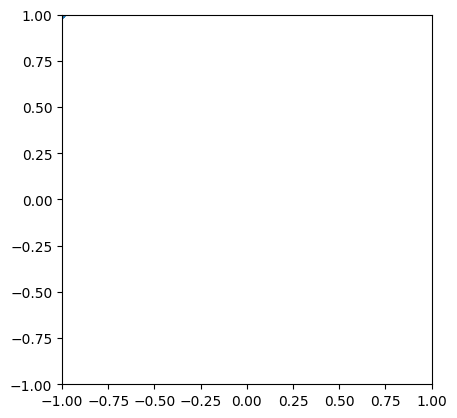

In [4]:
def calc_xy(a, b, c, d):
    return (a-b)/(a+b), (c-d)/(c+d)

x0, y0, z0, vz, vx, vy = cloud_init(natoms=1000, sigma_cloud=1e-3, sigma_transverse_v=0.1*3.5e-3/omega_r_conversion, sigma_vertical_v=0.1*3.5e-3)

cphases = np.linspace(0, 2*np.pi, 12)
x, y = np.full_like(cphases, np.nan), np.full_like(cphases, np.nan)
for i in range(len(cphases)):
    pA, pB, pC, pD = cpops(x0, y0, z0, vz, vx, vy, cphase=cphases[i], injected_dphase=np.pi/8)
    x[i], y[i] = calc_xy(np.sum(pA), np.sum(pB), np.sum(pC), np.sum(pD))

plt.plot(x, y, '.')
plt.gca().set_aspect('equal')
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.show()